In [61]:
# import libreri E-commerse sales data analysis project
import numpy as np
import pandas as pd

In [62]:
# loading data 
df=pd.read_csv("data (1).csv", encoding='ISO-8859-1')
df

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,12/1/2010 8:26,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,12/1/2010 8:26,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,12/1/2010 8:26,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,12/1/2010 8:26,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,12/1/2010 8:26,3.39,17850.0,United Kingdom
...,...,...,...,...,...,...,...,...
541904,581587,22613,PACK OF 20 SPACEBOY NAPKINS,12,12/9/2011 12:50,0.85,12680.0,France
541905,581587,22899,CHILDREN'S APRON DOLLY GIRL,6,12/9/2011 12:50,2.10,12680.0,France
541906,581587,23254,CHILDRENS CUTLERY DOLLY GIRL,4,12/9/2011 12:50,4.15,12680.0,France
541907,581587,23255,CHILDRENS CUTLERY CIRCUS PARADE,4,12/9/2011 12:50,4.15,12680.0,France


In [63]:
df.shape

(541909, 8)

In [64]:
df.columns

Index(['InvoiceNo', 'StockCode', 'Description', 'Quantity', 'InvoiceDate',
       'UnitPrice', 'CustomerID', 'Country'],
      dtype='object')

In [65]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   InvoiceNo    541909 non-null  object 
 1   StockCode    541909 non-null  object 
 2   Description  540455 non-null  object 
 3   Quantity     541909 non-null  int64  
 4   InvoiceDate  541909 non-null  object 
 5   UnitPrice    541909 non-null  float64
 6   CustomerID   406829 non-null  float64
 7   Country      541909 non-null  object 
dtypes: float64(2), int64(1), object(5)
memory usage: 33.1+ MB


In [66]:
# statistical summery
df.describe()

,Quantity,UnitPrice,CustomerID
count,541909.000000,541909.000000,406829.000000
mean,9.552250,4.611114,15287.690570
std,218.081158,96.759853,1713.600303
min,-80995.000000,-11062.060000,12346.000000
25%,1.000000,1.250000,13953.000000
50%,3.000000,2.080000,15152.000000
75%,10.000000,4.130000,16791.000000
max,80995.000000,38970.000000,18287.000000


In [67]:
df.isnull().sum()

InvoiceNo           0
StockCode           0
Description      1454
Quantity            0
InvoiceDate         0
UnitPrice           0
CustomerID     135080
Country             0
dtype: int64

In [68]:
df=df.dropna(subset=["CustomerID"])

In [69]:
df.shape

(406829, 8)

In [70]:
df.isnull().sum()

InvoiceNo      0
StockCode      0
Description    0
Quantity       0
InvoiceDate    0
UnitPrice      0
CustomerID     0
Country        0
dtype: int64

In [110]:
df=df.drop_duplicates()
df.shape

(392732, 14)

In [111]:
# Handle cancelled Order Important data 
# Agar InvoiceNO me C hai -order cancelled hai
df=df[~df['InvoiceNo'].astype(str).str.contains('C')]

In [112]:
df.shape

(392732, 14)

In [113]:
df=df[df['Quantity']>0]

In [114]:
# conver date columns
df["InvoiceDate"] = pd.to_datetime(df["InvoiceDate"])

In [117]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 392732 entries, 0 to 541908
Data columns (total 14 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   InvoiceNo    392732 non-null  object        
 1   StockCode    392732 non-null  object        
 2   Description  392732 non-null  object        
 3   Quantity     392732 non-null  int64         
 4   InvoiceDate  392732 non-null  datetime64[ns]
 5   UnitPrice    392732 non-null  float64       
 6   CustomerID   392732 non-null  float64       
 7   Country      392732 non-null  object        
 8   Revenue      392732 non-null  float64       
 9   Day          392732 non-null  object        
 10  Month        392732 non-null  int32         
 11  Year         392732 non-null  int32         
 12  Date         392732 non-null  object        
 13  DayName      392732 non-null  object        
dtypes: datetime64[ns](1), float64(3), int32(2), int64(1), object(7)
memory usage: 41.9+ MB


In [115]:
df["Revenue"] = df["Quantity"] * df["UnitPrice"] ## Revenue = Quantity × UnitPrice

In [116]:
df.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,Revenue,Day,Month,Year,Date,DayName
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom,15.30,Wednesday,12,2010,2010-12-01,Wednesday
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34,Wednesday,12,2010,2010-12-01,Wednesday
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom,22.00,Wednesday,12,2010,2010-12-01,Wednesday
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34,Wednesday,12,2010,2010-12-01,Wednesday
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34,Wednesday,12,2010,2010-12-01,Wednesday


In [78]:
df["Day"] = df["InvoiceDate"].dt.day_name()


In [79]:
# month nikalna

In [80]:
df["Month"] = df["InvoiceDate"].dt.month


In [81]:
# year kaise nikalna

In [82]:
df["Year"] = df["InvoiceDate"].dt.year

In [118]:
df.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,Revenue,Day,Month,Year,Date,DayName
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom,15.30,Wednesday,12,2010,2010-12-01,Wednesday
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34,Wednesday,12,2010,2010-12-01,Wednesday
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom,22.00,Wednesday,12,2010,2010-12-01,Wednesday
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34,Wednesday,12,2010,2010-12-01,Wednesday
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34,Wednesday,12,2010,2010-12-01,Wednesday


In [84]:
# EDA ()Explorarory Data Analysis

In [119]:
total_revenue=df['Revenue'].sum()
total_revenue

8887208.894000003

In [120]:
monthly_sales = df.groupby("Month")["Revenue"].sum()
print(monthly_sales)

Month
1      568101.310
2      446084.920
3      594081.760
4      468374.331
5      677355.150
6      660046.050
7      598962.901
8      644051.040
9      950690.202
10    1035642.450
11    1156205.610
12    1087613.170
Name: Revenue, dtype: float64


In [121]:
#3. Daily Revenue trends निकालना

In [122]:
df["Revenue"] = df["Quantity"] * df["UnitPrice"]

daily_revenue = df.groupby("Date")["Revenue"].sum()
print(daily_revenue.head())


Date
2010-12-01    46192.49
2010-12-02    47197.57
2010-12-03    23876.63
2010-12-05    31361.28
2010-12-06    31009.33
Name: Revenue, dtype: float64


In [123]:
df.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,Revenue,Day,Month,Year,Date,DayName
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom,15.30,Wednesday,12,2010,2010-12-01,Wednesday
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34,Wednesday,12,2010,2010-12-01,Wednesday
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom,22.00,Wednesday,12,2010,2010-12-01,Wednesday
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34,Wednesday,12,2010,2010-12-01,Wednesday
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34,Wednesday,12,2010,2010-12-01,Wednesday


In [124]:
top_countries = df["Country"].value_counts().head(10)
print(top_countries)


Country
United Kingdom    349227
Germany             9027
France              8327
EIRE                7228
Spain               2480
Netherlands         2363
Belgium             2031
Switzerland         1842
Portugal            1453
Australia           1184
Name: count, dtype: int64


In [126]:
top_revenue_countries = df.groupby("Country")["Revenue"].sum().sort_values(ascending=False).head(10) # top revenue by country
print(top_revenue_countries)


Country
United Kingdom    7285024.644
Netherlands        285446.340
EIRE               265262.460
Germany            228678.400
France             208934.310
Australia          138453.810
Spain               61558.560
Switzerland         56443.950
Belgium             41196.340
Sweden              38367.830
Name: Revenue, dtype: float64


# Product Analysis

In [125]:
best_salling_product = df.groupby("Description")["Revenue"].sum().sort_values(ascending=False).head(10)
print(best_salling_product)

Description
PAPER CRAFT , LITTLE BIRDIE           168469.60
REGENCY CAKESTAND 3 TIER              142264.75
WHITE HANGING HEART T-LIGHT HOLDER    100392.10
JUMBO BAG RED RETROSPOT                85040.54
MEDIUM CERAMIC TOP STORAGE JAR         81416.73
POSTAGE                                77803.96
PARTY BUNTING                          68785.23
ASSORTED COLOUR BIRD ORNAMENT          56413.03
Manual                                 53419.93
RABBIT NIGHT LIGHT                     51251.24
Name: Revenue, dtype: float64


In [138]:
df["Quantity"] = df["Quantity"].astype(str)              # ensure string
df["Quantity"] = df["Quantity"].str.replace(",", "")     # remove commas
df["Quantity"] = df["Quantity"].astype(int)              # convert to int

In [139]:
returned_products = df[df["Quantity"] < 0] # मान लो कि negative quantity = return।

In [140]:
product_returns = returned_products.groupby("Description")["Quantity"].sum() # Product‑wise Return Quantity jodta hai

In [141]:
most_returned = product_returns.sort_values().head(1) # Most Returned Product nikalta hai
print(most_returned)


Series([], Name: Quantity, dtype: int32)


In [142]:
print(df["Quantity"].min()) # अगर minimum value positive है, तो dataset में return data नहीं है।

1


In [ ]:
#आपके dataset में अगर Sales column नहीं है, तो भी आप Highest Revenue Product निकाल सकते हो। Revenue निकालने के लिए हमें Quantity × UnitPrice करना होगा।

In [144]:
# hight revenua product
product_revenue = df.groupby("Description")["Revenue"].sum()

In [145]:
high_revenue_product = product_revenue.sort_values(ascending=False).head(1)
print(high_revenue_product)

Description
PAPER CRAFT , LITTLE BIRDIE    168469.6
Name: Revenue, dtype: float64


# Customer analysis

In [100]:
top_customer = df.groupby("CustomerID")["Revenue"].sum().sort_values(ascending=False) # CUSTOMER NAME NA RAHNE PER CUSTOMER ID SE BHI NIKAL SAKTE HAI
print(top_customer)

CustomerID
14646.0    280206.02
18102.0    259657.30
17450.0    194550.79
16446.0    168472.50
14911.0    143825.06
             ...    
17956.0        12.75
16454.0         6.90
14792.0         6.20
16738.0         3.75
13256.0         0.00
Name: Revenue, Length: 4339, dtype: float64


In [105]:
# Reapeat_customer
repeat_customers=df['CustomerID'].value_counts()
repeat_customers

CustomerID
17841.0    7847
14911.0    5677
14096.0    5111
12748.0    4596
14606.0    2700
           ... 
15313.0       1
17846.0       1
13185.0       1
16953.0       1
16737.0       1
Name: count, Length: 4339, dtype: int64

In [ ]:
df["Revenue"] = df["Quantity"] * df["UnitPrice"] # Revenue per Transaction FARMULA 


In [147]:
customer_revenue = df.groupby("CustomerID")["Revenue"].sum() # Customer‑wise Total Revenue
AOV = df.groupby("CustomerID")["Revenue"].sum() / df.groupby("CustomerID")["InvoiceNo"].nunique()
# Average Order Value (AOV) निकालो


In [148]:
# Purchase Frequency :-Total Orders ÷ Unique Customers
purchase_frequency = df["InvoiceNo"].nunique() / df["CustomerID"].nunique()

In [149]:
customer_value = AOV * purchase_frequency

In [152]:
lifespan_years = 5
CLV = customer_value.mean() * lifespan_years
CLV

8918.28734412415

In [154]:
print(customer_value.head(10))


CustomerID
12346.0    329724.639226
12347.0      2630.301913
12348.0      1919.430781
12349.0      7508.169348
12350.0      1428.540770
12352.0      1338.210343
12353.0       380.203734
12354.0      4611.145056
12355.0      1962.534778
12356.0      4003.431396
dtype: float64


In [108]:
df["DayName"] = df["InvoiceDate"].dt.day_name()


In [109]:
best_day = df.groupby("Day")["Revenue"].sum().sort_values(ascending=False)
print(best_day)


Day
Thursday     1976859.070
Tuesday      1700634.631
Wednesday    1588336.170
Friday       1485917.401
Monday       1367146.411
Sunday        792514.221
Name: Revenue, dtype: float64


# Data visualization

### monthly sales  using by bar chart 

In [101]:
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
# FIRST CHART (1)

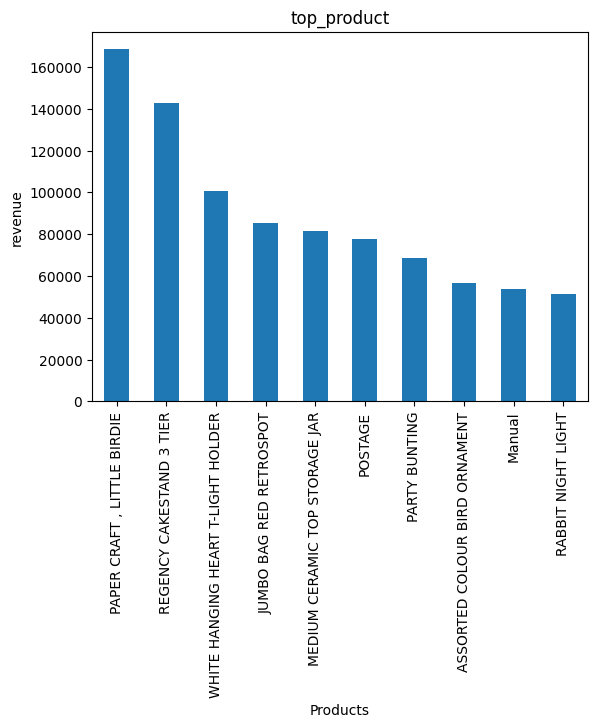

In [103]:
top_product.plot(kind='bar')
plt.title("top_product")
plt.xlabel("Products")
plt.ylabel("revenue")

plt.show()

In [ ]:
# SECOND CHART (2)

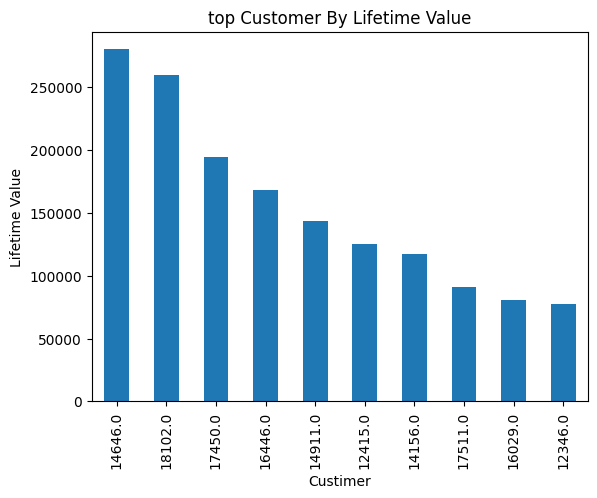

In [156]:
customer_revenue.sort_values(ascending=False).head(10).plot(kind="bar")
plt.title("top Customer By Lifetime Value")
plt.xlabel("Custimer")
plt.ylabel("Lifetime Value")
plt.show()

In [ ]:
# THIRD CHART (3)

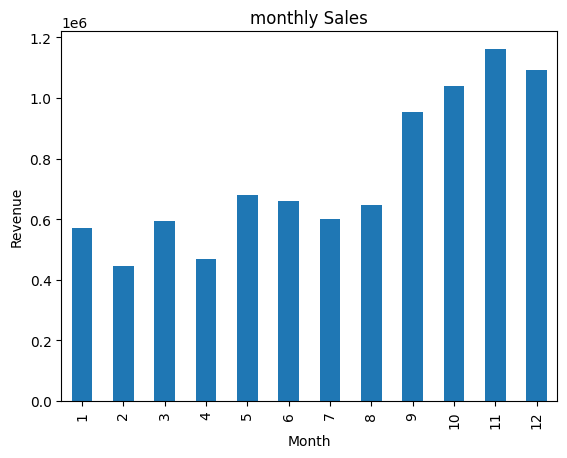

In [102]:
monthly_sales.plot(kind='bar')
plt.title("monthly Sales")
plt.xlabel("Month")
plt.ylabel("Revenue")
plt.show()

In [ ]:
# FOURTH CHART (4)

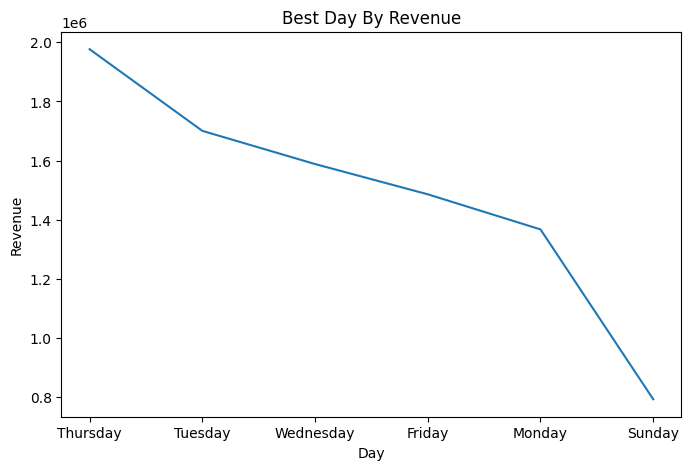

In [159]:
best_day.plot(kind='line', figsize=(8,5))
plt.title("Best Day By Revenue")
plt.xlabel("Day")
plt.ylabel("Revenue")
plt.show()

In [ ]:
# FIFTH CHART (5)

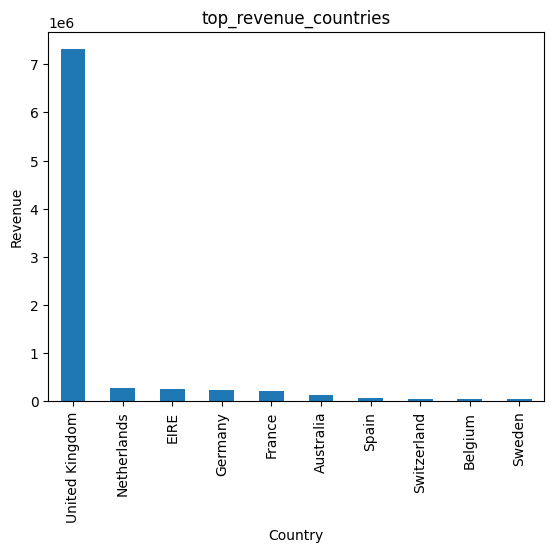

In [104]:
top_revenue_countries.plot(kind='bar')
plt.title("top_revenue_countries")
plt.xlabel("Country")
plt.ylabel("Revenue")
plt.show()

# Business insights

In [ ]:
# (Top product)- Bar Chart Insights
''' (1)Top Revenue Products  
        -The chart clearly shows which products generate the highest revenue.
        -Insight: Focus more on these products with increased inventory and marketing campaigns.
    (2)Low Revenue Products  
        -Some products contribute very little revenue.
        -Insight: These may need discounts, re‑pricing, or even discontinuation.
    (3)Revenue Concentration  
        -If only a few products dominate revenue, the business is highly dependent on them.
        -Insight: Diversify the product portfolio to reduce risk.
    (4)Customer Preference Patterns  
        -High‑revenue products reflect customer demand and preferences.
        -Insight: Launch similar variants or bundles to maximize sales.
    (5)Strategic Planning  
        -The chart highlights which products are the backbone of future growth.
        -Insight: Prioritize these products in supply chain, stock management, and promotions.

In [ ]:
# Top Customer by Lifetime Value" Bar Chart
''' (1)High Value Customers  
        -Customers such as 14646.0 and 18102.0 generate the highest lifetime value (above 250,000).
        -Insight: These are the most valuable customers. Retention strategies like loyalty programs, personalized offers, and premium services should be prioritized for them.
    
    (2)Medium Value Customers  
        -Customers like 17450.0, 16446.0, 14911.0 show moderate lifetime value.
        -Insight: With targeted marketing, upselling, and engagement, they can be converted into high‑value customers.
    
    (3)Low Value Customers  
        -Customers such as 16029.0 and 12346.0 have relatively low lifetime value (below 100,000).
        -Insight: They need re‑engagement through discounts, referral programs, or re‑activation campaigns.
    
    (4)Revenue Concentration Risk  
        -A large portion of revenue is concentrated among a few top customers.
        -Insight: If these customers churn, the business faces significant risk. Strong retention strategies are critical.
    
    (5)Segmentation Opportunity  
        -Customers can be segmented into High, Medium, and Low CLV groups.
        -Insight: Different marketing and sales strategies should be designed for each segment to maximize overall business value.

In [ ]:
# Monthly Sales Revenue
'''(1) Peak Months  
        -The chart highlights which months generated the highest revenue.
        -Insight: These months represent strong customer demand. Businesses should increase inventory, marketing, and promotions during these periods to maximize profit.
    
    (2)Low Months  
        -Some months show significantly lower revenue.
        -Insight: These months require special offers, discounts, or targeted campaigns to boost sales and reduce idle capacity.
    
    (3)Seasonality Patterns  
        -If certain months consistently show higher revenue (e.g., festive seasons), this indicates seasonal demand.
        -Insight: Businesses should plan stock, staffing, and advertising in advance to capitalize on these seasonal peaks.
    
    (4)Revenue Stability vs Fluctuation  
        -A smooth chart suggests stable demand, while sharp ups and downs indicate volatility.
        -Insight: Stable demand allows predictable planning, while fluctuating demand requires flexible forecasting and agile supply chain management.
    
    (5)Strategic Timing  
        -The chart reveals the best months to launch new products or promotional campaigns.
        -Insight: Aligning launches with high‑revenue months ensures maximum visibility and customer engagement.

In [ ]:
# Best Day by Revenue (Line Chart )
''' (1)Peak Day Identification  
        -The line chart highlights which specific day generated the highest revenue.
        -Insight: This day represents strong customer demand, making it ideal for inventory expansion and targeted marketing campaigns.
    
    (2)Low Revenue Days  
        -The dips in the line chart show days with minimal sales.
        -Insight: These days can be improved through special offers, discounts, or promotional activities.
    
    (3)Weekly Pattern / Seasonality  
        -If certain days (e.g., Fridays or Sundays) consistently show higher revenue, it indicates a customer buying pattern.
        -Insight: Businesses should align staffing, stock management, and promotions with these recurring high‑demand days.
    
    (4)Revenue Stability vs Fluctuation  
        -A smooth line suggests stable daily demand, while sharp peaks and dips indicate volatility.
        -Insight: Stable demand allows predictable planning, while fluctuating demand requires flexible forecasting and agile supply chain management.
    
    (5)Strategic Timing  
        -The chart reveals the best day(s) to launch new products or promotional campaigns.
        -Insight: Aligning launches with high‑revenue days ensures maximum visibility and customer engagement.

In [ ]:
# Top Countries by Revenue( Bar Chart)
'''(1)High Revenue Countries
        -Chart clearly shows which countries contribute the maximum revenue.
        -Insight: These countries are the strongest markets. Business should invest more in marketing, logistics, and customer engagement here to strengthen dominance.
    
    (2)Medium Revenue Countries
        -Some countries generate moderate revenue.
        -Insight: With targeted campaigns, localized offers, and better distribution, these can be converted into high‑revenue markets.
    
    (3)Low Revenue Countries
        -A few countries contribute very little revenue.
        -Insight: Either demand is low or awareness is missing. Businesses can test promotions, partnerships, or decide whether to continue operations in these regions.
    
    (4)Revenue Concentration Risk
        -If most revenue is coming from only a few countries, the business is highly dependent on them.
        -Insight: Diversification is important. Expanding into other regions reduces risk if one major market slows down.
    
    (5)Strategic Expansion Opportunity
        -The chart highlights untapped potential markets.
        Insight: Countries with growing but not yet high revenue can be targeted for expansion with localized strategies.-

In [163]:
df.to_csv("cleaned_ecommerce_data.csv", index=False)